# Non-unitarity of spin-triplet superconductors
For a spin-triplet superconductor the pairing is a symmetric $2\times2$ matrix in spin space,
parametrized by a complex d-vector as $\Delta = i(\vec d\cdot\vec\sigma)\sigma_y$. What separates
two classes of triplet states is the product

$$
\Delta \Delta^\dagger = |\vec d|^2 \mathbb{1} + \vec q \cdot \vec \sigma,
\qquad
\vec q = i (\vec d \times \vec d^*)
$$

When $\vec q = 0$ the state is unitary and the Cooper pairs carry no net spin; when
$\vec q \neq 0$ it is non-unitary, the gap is different for the two spin branches, and $\vec q$
is the spin moment of the Cooper pairs. `h.get_dvector_non_unitarity()` returns $\vec q$ per
site, and `h.write_non_unitarity()` writes it as a real-space map.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry

### Non-unitarity needs a relative phase
Let us put in by hand a p-wave pairing on a chain with $\vec d \propto (1,\eta e^{i\alpha},0)$.
A d-vector whose components share a common phase is always unitary, so $\vec q$ vanishes at
$\alpha=0$ and $\alpha=\pi$ whatever $\eta$ is; it is largest for $\vec d\propto(1,\pm i,0)$, a
pure $\Delta_{\uparrow\uparrow}$ or $\Delta_{\downarrow\downarrow}$ pairing, where the pair spin
points along $\pm z$.

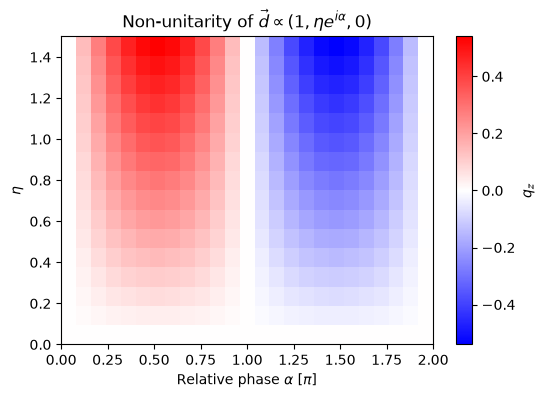

In [2]:
g = geometry.chain() # geometry of the 1D model
etas = np.linspace(0.,1.5,16) # relative amplitude of d_y
alphas = np.linspace(0.,2*np.pi,25) # relative phase of d_y
qz = np.zeros((len(etas),len(alphas)))
for i,eta in enumerate(etas):
    for j,alpha in enumerate(alphas):
        h = g.get_hamiltonian() # first-neighbor hopping
        h.add_pairing(delta=0.3,mode="pwave",d=[1.,eta*np.exp(1j*alpha),0.])
        qz[i,j] = h.get_dvector_non_unitarity(nk=20)[0,2] # q_z of the only site

plt.figure(figsize=(6,4))
plt.imshow(qz,origin="lower",aspect="auto",cmap="bwr",
           extent=[0.,2.,etas[0],etas[-1]],vmin=-np.max(np.abs(qz)),vmax=np.max(np.abs(qz)))
plt.colorbar(label="$q_z$")
plt.xlabel("Relative phase $\\alpha$ [$\\pi$]") ; plt.ylabel("$\\eta$")
plt.title("Non-unitarity of $\\vec d \\propto (1,\\eta e^{i\\alpha},0)$")
plt.show()

### A self-consistent ferromagnetic superconductor
Non-unitary states also arise on their own. Attractive first-neighbor interactions on top of a
large exchange field give rise, at the mean-field level, to a spin-triplet state, and since the
pairs form in the majority band their spin follows the magnetization.

In [3]:
g = geometry.triangular_lattice() # generate the geometry
h = g.get_hamiltonian() # create Hamiltonian of the system
h.add_exchange([0.,0.,3.]) # add exchange field
h.setup_nambu_spinor() # initialize the Nambu basis
# perform a superconducting non-collinear mean-field calculation
h = h.get_mean_field_hamiltonian(V1=-1.0,filling=0.3,mf="random",nk=4,verbose=0)
print("q =",h.get_dvector_non_unitarity()[0]) # pair spin
print("m =",h.get_magnetization()[0]) # magnetization, parallel to q

q = [ 3.58956571e-10 -9.66193380e-10 -3.78024926e-02]
m = [ 2.49787805e-11 -4.50320374e-10 -7.49615479e-01]


### A real-space map of the pair spin
In an inhomogeneous system $\vec q$ changes from site to site. We now put in by hand, on a
$6\times6$ supercell of the triangular lattice, an equal-spin pairing whose spin axis follows a
texture $\vec n(\vec r)$, taking $\vec d = \hat e_\theta + i\hat e_\phi$ with $\hat e_\theta$ and
$\hat e_\phi$ perpendicular to $\vec n$, so that $\vec q \propto \hat e_\theta\times\hat e_\phi
= \vec n$. This is what the pairing of a ferromagnetic superconductor looks like when the pairs
form in the local majority band of a magnetic texture. The per-site $\vec q$ computed from the
BdG Hamiltonian gives back that texture: the color is $q_z$ and the arrows its in-plane part.

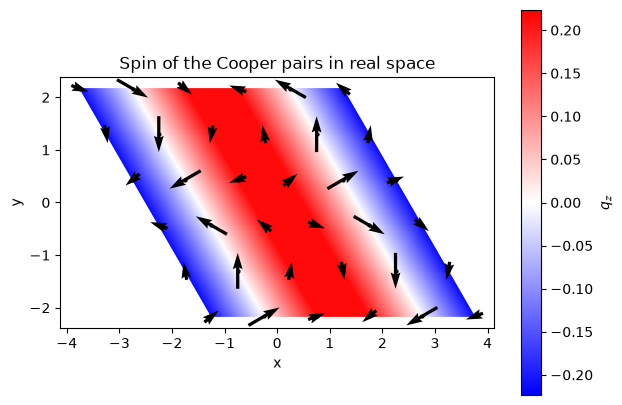

In [4]:
n = 6 # size of the supercell
g = geometry.triangular_lattice().get_supercell(n) # 36 sites
B = np.array([g.a1[:2],g.a2[:2]]).T # supercell vectors, as columns
def dvector(r):
    (f1,f2) = np.linalg.solve(B,r[:2]) # fractional coordinates in the supercell
    th,ph = 2*np.pi*f1,2*np.pi*f2 # polar and azimuthal angle of the texture
    eth = np.array([np.cos(th)*np.cos(ph),np.cos(th)*np.sin(ph),-np.sin(th)])
    eph = np.array([-np.sin(ph),np.cos(ph),0.])
    return (eth + 1j*eph)/2. # q is parallel to eth x eph

h = g.get_hamiltonian() # first-neighbor hopping
h.add_pairing(delta=0.3,mode="pwave",d=dvector) # textured non-unitary pairing
q = h.get_dvector_non_unitarity(nk=4) # pair spin, one row per site

x,y = g.r[:,0],g.r[:,1]
plt.figure(figsize=(7,5))
plt.tripcolor(x,y,q[:,2],shading="gouraud",cmap="bwr",
              vmin=-np.max(np.abs(q)),vmax=np.max(np.abs(q)))
plt.colorbar(label="$q_z$")
plt.quiver(x,y,q[:,0],q[:,1],color="black",pivot="mid") # in-plane part
plt.scatter(x,y,c="black",s=4)
plt.gca().set_aspect("equal")
plt.xlabel("x") ; plt.ylabel("y")
plt.title("Spin of the Cooper pairs in real space")
plt.show()